In [ ]:
!pip install torch torchvision matplotlib
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from PIL import Image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 31.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 39.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 39.5 MB/s eta 0:00:00


## **Convolutional Operation**

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, GridspecLayout, Output, VBox
from IPython.display import display, clear_output

# Load the image
image_path = '/content/stones.jpg'  # Replace with your image path
image = Image.open(image_path)

# Define a transform to convert the image to a tensor
preprocess = transforms.Compose([transforms.ToTensor()])

# Preprocess the image
input_tensor = preprocess(image)
input_tensor = input_tensor.unsqueeze(0)  # Add a batch dimension

# Initialize convolution kernels
kernel_names = ["Gaussian", "Sharp", "Ridge", "Edge", "Identity"]
kernels = {
    "Gaussian": np.array([[1, 2, 1],
                          [2, 4, 2],
                          [1, 2, 1]], dtype=np.float32) / 16,
    "Sharp": np.array([[0, -1, 0],
                      [-1, 5, -1],
                      [0, -1, 0]], dtype=np.float32),
    "Ridge": np.array([[0, -1, 0],
                      [-1, 4, -1],
                      [0, -1, 0]], dtype=np.float32),
    "Edge": np.array([[-1, -1, -1],
                    [-1, 8, -1],
                    [-1, -1, -1]], dtype=np.float32),
    "Identity": np.array([[0, 0, 0],
                        [0, 1, 0],
                        [0, 0, 0]], dtype=np.float32)
}

# Create a function to apply convolution and update the displayed images
class KnownConvolution(nn.Module):
    def __init__(self, kernel, channels):
        super(KnownConvolution, self).__init__()
        self.channels = channels
        self.conv_layers = nn.ModuleList([nn.Conv2d(1, 1, kernel_size=kernel.shape[0], bias=False) for _ in range(self.channels)])

        for layer in self.conv_layers:
            layer.weight = nn.Parameter(torch.from_numpy(kernel).unsqueeze(0).unsqueeze(0))
            layer.weight.requires_grad = False

    def forward(self, x):
        convolved_channels = [layer(x[:, i:i+1, :, :]) for i, layer in enumerate(self.conv_layers)]
        return torch.cat(convolved_channels, dim=1)

# Create a grid-based widget for Known kernel input
known_kernel_input = GridspecLayout(3, 3, width='1000px', height='150px')
known_kernel_text_inputs = []

for i in range(3):
    row = []
    for j in range(3):
        row.append(widgets.FloatText(value=0, description=f"Row {i+1}, Col {j+1}"))
    known_kernel_text_inputs.append(row)

for i in range(3):
    for j in range(3):
        known_kernel_input[i, j] = known_kernel_text_inputs[i][j]

# Initialize modified image variable as a global variable
modified_image = input_tensor.clone()

# Initialize the kernel with a default value of zeros
dynamic_kernel = np.zeros((3, 3), dtype=np.float32)

# Display the output images in one place
output_image = widgets.Output(layout={'border': '1px solid black'})
display(output_image)

# Function to visualize the kernel matrix as an image
def visualize_kernel(kernel, ax, cbar_ax):
    # Normalize the kernel matrix to values between 0 and 1
    normalized_kernel = (kernel - np.min(kernel)) / (np.max(kernel) - np.min(kernel))
    # Display the kernel as an image
    im = ax.imshow(normalized_kernel, cmap='viridis', interpolation='nearest')
    ax.title.set_text('Kernel Visualization')
    ax.axis('off')
    plt.colorbar(im, cax=cbar_ax, orientation='vertical', fraction=0.046, pad=0.04)

# Function to apply convolution and update the displayed images
def apply_convolution(_):
    global modified_image, dynamic_kernel

    # Get the values from the known kernel text inputs
    dynamic_kernel = np.array([[known_kernel_text_inputs[i][j].value for j in range(3)] for i in range(3)], dtype=np.float32)
    known_convolution = KnownConvolution(dynamic_kernel, channels=3)

    # Apply convolution
    with torch.no_grad():
        result = known_convolution(input_tensor)
    modified_image = result.clone()

    with output_image:
        clear_output(wait=True)

        # Set up the figure layout with GridSpec
        fig = plt.figure(figsize=(12, 4))  # Adjust the figsize to scale your plots
        gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05])  # Adjust width ratios to match the layout
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[0, 2])
        cbar_ax = fig.add_subplot(gs[0, 3])

        # Original Image
        ax1.imshow(input_tensor.squeeze(0).permute(1, 2, 0))
        ax1.set_title('Original Image')
        ax1.axis('off')

        # Convoluted Image
        ax2.imshow(modified_image.squeeze(0).permute(1, 2, 0).clip(0, 1))
        ax2.set_title('Convoluted Image')
        ax2.axis('off')

        # Kernel Visualization
        visualize_kernel(dynamic_kernel, ax3, cbar_ax)

        plt.tight_layout()
        plt.show()

def save_convolved_image(_):
    #clip the color to 0 and 1 then convert to uint8
    convolved_img = modified_image.squeeze(0).permute(1, 2, 0).detach().numpy().clip(0, 1) * 255
    print(convolved_img.size)
    # convolved_img = modified_image.squeeze(0).permute(1, 2, 0).detach().numpy() * 255
    convolved_img = convolved_img.astype(np.uint8)
    convolved_img_pil = Image.fromarray(convolved_img)
    convolved_img_pil.save('/content/convoluted_image1.jpg')
    print("Convoluted image saved successfully!")

# Function to update the known kernel
def update_known_kernel(kernel):
    for i in range(3):
        for j in range(3):
            known_kernel_text_inputs[i][j].value = kernel[i, j]

# Create a dropdown widget for selecting the kernel type
kernel_dropdown = widgets.Dropdown(
    options=kernel_names,
    description="Kernel Type:",
    disabled=False,
)

# Register the apply_convolution function to be called when the dropdown value changes
def dropdown_change(change):
    kernel_type = change.new
    if kernel_type == "Gaussian":
        # Enable the known kernel input
        for row in known_kernel_text_inputs:
            for text_input in row:
                text_input.disabled = False
    else:
        # Disable the known kernel input for predefined kernels
        for row in known_kernel_text_inputs:
            for text_input in row:
                text_input.disabled = True
        # Update the known kernel based on the selected type
        dynamic_kernel = kernels[kernel_type]
        update_known_kernel(dynamic_kernel)
        # Apply the convolution with the updated known kernel
        apply_convolution(None)

kernel_dropdown.observe(dropdown_change, names='value')

# Create a button to update the known kernel
update_button = widgets.Button(description="Update Known Kernel")
update_button.on_click(apply_convolution)  # Call apply_convolution when the button is clicked

# Create a button to save the convolved image
save_button = widgets.Button(description="Save Convoluted Image")
save_button.on_click(save_convolved_image)  # Call save_convolved_image when the button is clicked

# Assemble UI components in a vertical box layout
ui_elements = VBox([
    kernel_dropdown,
    known_kernel_input,
    update_button,
    save_button
])

# Display the UI elements
display(ui_elements)

# Display the output image area
output_image = Output()
display(output_image)

# Initialize with default kernel
default_kernel = kernels['Gaussian']
update_known_kernel(default_kernel)

# Apply convolution with the default kernel on start
apply_convolution(None)


Output(layout=Layout(border='1px solid black'))

Output()

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widgets, GridspecLayout, Output, VBox
from IPython.display import display, clear_output

# Load the image
image_path = '/content/stones.jpg'  # Replace with your image path
image = Image.open(image_path)

# Define a transform to convert the image to a tensor
preprocess = transforms.Compose([transforms.ToTensor()])

# Preprocess the image
input_tensor = preprocess(image)
input_tensor = input_tensor.unsqueeze(0)  # Add a batch dimension

# Initialize convolution kernels
kernel_names = ["Custom"]
kernels = {
    "Custom": np.array([[0, 0, 0],
                        [0, 1, 0],
                        [0, 0, 0]], dtype=np.float32)
}

# Create a function to apply convolution and update the displayed images
class CustomConvolution(nn.Module):
    def __init__(self, kernel, channels):
        super(CustomConvolution, self).__init__()
        self.channels = channels
        self.conv_layers = nn.ModuleList([nn.Conv2d(1, 1, kernel_size=kernel.shape[0], bias=False) for _ in range(self.channels)])

        for layer in self.conv_layers:
            layer.weight = nn.Parameter(torch.from_numpy(kernel).unsqueeze(0).unsqueeze(0))
            layer.weight.requires_grad = False

    def forward(self, x):
        convolved_channels = [layer(x[:, i:i+1, :, :]) for i, layer in enumerate(self.conv_layers)]
        return torch.cat(convolved_channels, dim=1)

# Create a grid-based widget for custom kernel input
custom_kernel_input = GridspecLayout(3, 3, width='1000px', height='150px')
custom_kernel_text_inputs = []

for i in range(3):
    row = []
    for j in range(3):
        row.append(widgets.FloatText(value=0, description=f"Row {i+1}, Col {j+1}"))
    custom_kernel_text_inputs.append(row)

for i in range(3):
    for j in range(3):
        custom_kernel_input[i, j] = custom_kernel_text_inputs[i][j]

# Initialize modified image variable as a global variable
modified_image = input_tensor.clone()

# Initialize the kernel with a default value of zeros
dynamic_kernel = np.zeros((3, 3), dtype=np.float32)

# Display the output images in one place
output_image = widgets.Output(layout={'border': '1px solid black'})
display(output_image)

# Function to visualize the kernel matrix as an image
def visualize_kernel(kernel, ax, cbar_ax):
    # Normalize the kernel matrix to values between 0 and 1
    normalized_kernel = (kernel - np.min(kernel)) / (np.max(kernel) - np.min(kernel))
    # Display the kernel as an image
    im = ax.imshow(normalized_kernel, cmap='viridis', interpolation='nearest')
    ax.title.set_text('Kernel Visualization')
    ax.axis('off')
    plt.colorbar(im, cax=cbar_ax, orientation='vertical', fraction=0.046, pad=0.04)

# Function to apply convolution and update the displayed images
def apply_convolution(_):
    global modified_image, dynamic_kernel

    # Get the values from the custom kernel text inputs
    dynamic_kernel = np.array([[custom_kernel_text_inputs[i][j].value for j in range(3)] for i in range(3)], dtype=np.float32)
    custom_convolution = CustomConvolution(dynamic_kernel, channels=3)

    # Apply convolution
    with torch.no_grad():
        result = custom_convolution(input_tensor)
    modified_image = result.clone()

    with output_image:
        clear_output(wait=True)

        # Set up the figure layout with GridSpec
        fig = plt.figure(figsize=(12, 4))  # Adjust the figsize to scale your plots
        gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05])  # Adjust width ratios to match the layout
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[0, 2])
        cbar_ax = fig.add_subplot(gs[0, 3])

        # Original Image
        ax1.imshow(input_tensor.squeeze(0).permute(1, 2, 0))
        ax1.set_title('Original Image')
        ax1.axis('off')

        # Convoluted Image
        ax2.imshow(modified_image.squeeze(0).permute(1, 2, 0).clip(0, 1))
        ax2.set_title('Convoluted Image')
        ax2.axis('off')

        # Kernel Visualization
        visualize_kernel(dynamic_kernel, ax3, cbar_ax)

        plt.tight_layout()
        plt.show()

def save_convolved_image(_):
    #clip the color to 0 and 1 then convert to uint8
    convolved_img = modified_image.squeeze(0).permute(1, 2, 0).detach().numpy().clip(0, 1) * 255
    print(convolved_img.size)
    # convolved_img = modified_image.squeeze(0).permute(1, 2, 0).detach().numpy() * 255
    convolved_img = convolved_img.astype(np.uint8)
    convolved_img_pil = Image.fromarray(convolved_img)
    convolved_img_pil.save('/content/convoluted_image1.jpg')
    print("Convoluted image saved successfully!")

# Function to update the custom kernel
def update_custom_kernel(kernel):
    for i in range(3):
        for j in range(3):
            custom_kernel_text_inputs[i][j].value = kernel[i, j]

# Create a dropdown widget for selecting the kernel type
kernel_dropdown = widgets.Dropdown(
    options=kernel_names,
    description="Kernel Type:",
    disabled=False,
)

# Register the apply_convolution function to be called when the dropdown value changes
def dropdown_change(change):
    kernel_type = change.new
    if kernel_type == "Custom":
        # Enable the custom kernel input
        for row in custom_kernel_text_inputs:
            for text_input in row:
                text_input.disabled = False
    else:
        # Disable the custom kernel input for predefined kernels
        for row in custom_kernel_text_inputs:
            for text_input in row:
                text_input.disabled = True
        # Update the custom kernel based on the selected type
        dynamic_kernel = kernels[kernel_type]
        update_custom_kernel(dynamic_kernel)
        # Apply the convolution with the updated custom kernel
        apply_convolution(None)

kernel_dropdown.observe(dropdown_change, names='value')

# Create a button to update the custom kernel
update_button = widgets.Button(description="Update Custom Kernel")
update_button.on_click(apply_convolution)  # Call apply_convolution when the button is clicked

# Create a button to save the convolved image
save_button = widgets.Button(description="Save Convoluted Image")
save_button.on_click(save_convolved_image)  # Call save_convolved_image when the button is clicked

# Assemble UI components in a vertical box layout
ui_elements = VBox([
    kernel_dropdown,
    custom_kernel_input,
    update_button,
    save_button
])

# Display the UI elements
display(ui_elements)

# Display the output image area
output_image = Output()
display(output_image)

# Initialize with default kernel
default_kernel = kernels['Custom']
update_custom_kernel(default_kernel)

# Apply convolution with the default kernel on start
apply_convolution(None)


Output(layout=Layout(border='1px solid black'))

Output()

## **Kernel Recovery**

Recovered 3x3 Kernel Matrix:



GridspecLayout(children=(FloatText(value=0.0746078, description='Row 1, Col 1', disabled=True, layout=Layout(g…

Mean Squared Error (MSE): 0.00010579529771348462


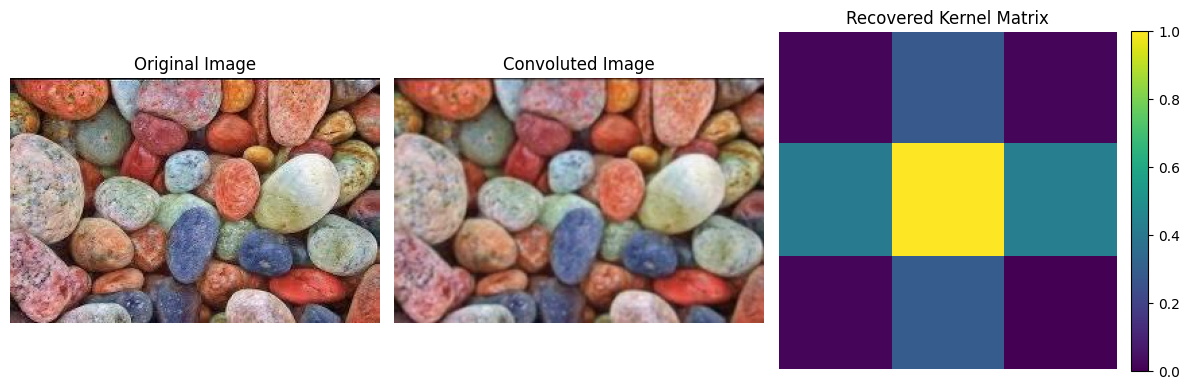

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load your original and convoluted images using PIL
original_img = Image.open("/content/stones.jpg")
convoluted_img = Image.open("/content/convoluted_image1.jpg")

# Convert them to tensors
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

original_image_tensor = transform(original_img)
convoluted_image_tensor = transform(convoluted_img)

class KernelRecoveryCNN(nn.Module):
    def __init__(self):
        super(KernelRecoveryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 1, kernel_size=3, bias=False)

    def forward(self, x):
        x = self.conv1(x)
        return x

# Initialize the Kernel Recovery CNN model
model = KernelRecoveryCNN()

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Define the number of epochs
num_epochs = 5000

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(original_image_tensor)
    loss = criterion(outputs, convoluted_image_tensor)
    loss.backward()
    optimizer.step()

# Calculate MSE
with torch.no_grad():
    model.eval()
    reconstructed_image = model(original_image_tensor)
    mse = criterion(reconstructed_image, convoluted_image_tensor)

# Retrieve the learned 3x3 kernel matrix from the model
recovered_kernel = model.conv1.weight.detach().squeeze().cpu().numpy()

# Create a grid of FloatText widgets to display the kernel values
custom_kernel_output = widgets.GridspecLayout(3, 3, width='1000px', height='150px')
for i in range(3):
    for j in range(3):
        formatted_value = "{:.7f}".format(recovered_kernel[i][j])
        custom_kernel_output[i, j] = widgets.FloatText(
            value=float(formatted_value),
            description=f"Row {i+1}, Col {j+1}",
            disabled=True,
            layout=widgets.Layout(width='auto')
        )

# Now you can display your FloatText grid
print("Recovered 3x3 Kernel Matrix:\n")
display(custom_kernel_output)

# Display the recovered 3x3 kernel matrix and MSE

print("Mean Squared Error (MSE):", mse.item())

# Visualize original image, convoluted image, and the kernel matrix
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original image
axes[0].imshow(original_img, cmap='gray')
axes[0].axis('off')  # Turn off axis
axes[0].set_title('Original Image')

# Convolved image
axes[1].imshow(convoluted_img, cmap='gray')
axes[1].axis('off')  # Turn off axis
axes[1].set_title('Convoluted Image')

# Kernel matrix
# Normalize the kernel matrix to values between 0 and 1
normalized_kernel = (recovered_kernel - np.min(recovered_kernel)) / (np.max(recovered_kernel) - np.min(recovered_kernel))
axes[2].imshow(normalized_kernel, cmap='viridis', interpolation='nearest')
axes[2].axis('off')  # Turn off axis
axes[2].set_title('Recovered Kernel Matrix')

# Show colorbar for the kernel matrix
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axes[2], orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
